# Day 23 — Software Performance and Final Validation

**Project:** Optical Camera Communication (OCC) Video Message Decoding
**Pipeline under test:** the one frozen on Day 22 (`../day22/final_pipeline.py`, `FINAL_CONFIG.json`). Nothing in it is changed here; the first cell proves that by hashing it against `FROZEN_MANIFEST.json`.

**What this notebook does**
1. Measures software performance: per-stage times, end-to-end runtime, decoder time, model size, memory.
2. Runs the final validation on the held-out TEST data (last 70 % of every signal) with the frozen configuration — and checks that the numbers are identical to the Day 21 opening, because nothing was allowed to change.
3. Compares the final method against the strongest simple baseline (Day 15 fixed threshold, most-confident-frame rule) on the same metrics.
4. Analyses the trade-off between decoding quality, robustness, complexity, runtime and model size.

**Read this first.** No ground truth exists for the videos. Decoded-message correctness is not measurable; BER is measurable only on synthetic signals of the *assumed* 92 bps model. Every real-data number is an internal-consistency indicator.

In [1]:
import json, hashlib, sys, time, tracemalloc, platform, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
HERE = Path.cwd(); ROOT = HERE.parent.parent
sys.path.insert(0, str(ROOT / "week03" / "day17")); sys.path.insert(0, str(ROOT / "week04" / "day22"))
from occlib import T92, decode, fixed_thr, phase_ensemble, indicators, agreement, ber, random_bits, synth, split, load_signal_v1

# ---- 0. prove the pipeline is the frozen one
FM = json.load(open(ROOT / "week04/day22/FROZEN_MANIFEST.json"))["artefacts"]
CFG = json.load(open(ROOT / "week04/day22/FINAL_CONFIG.json"))
for rel in ("final_pipeline.py", "FINAL_CONFIG.json", "week02/day11/occ_pipeline.py", "week03/day17/occlib.py", "week02/day11/configs/preprocess_v1.yaml"):
    p = (ROOT / "week04/day22" / rel) if rel in ("final_pipeline.py", "FINAL_CONFIG.json") else ROOT / rel
    h = hashlib.sha256(p.read_bytes()).hexdigest(); assert h == FM[rel], f"{rel} differs from the frozen version"
print("frozen artefacts verified:", CFG["frozen"], "| decoder:", CFG["decoder"]["sampling_rule"], "rule,", CFG["decoder"]["threshold"], "threshold, phase", CFG["synchronisation"]["phase_convention"])
print(platform.platform(), "| Python", platform.python_version(), "| numpy", np.__version__)

frozen artefacts verified: 2026-09-11 (Day 22) | decoder: nearest rule, fixed threshold, phase 0.0
Windows-11-10.0.26200-SP0 | Python 3.13.9 | numpy 2.3.5


## 1. Software performance

Stage times come from the frozen pipeline's own run on all four videos (`../day22/final_outputs/*/summary.json`, one pass each). Decoder-only times are re-measured here on the longest signal.

In [2]:
idx = json.load(open(ROOT / "week04/day22/final_outputs/index.json"))
stages = ["1_frame_extraction_s", "2_roi_selection_s", "3_signal_extraction_s", "4_preprocessing_s", "5_6_sync_and_decision_s", "end_to_end_s"]
print(f"{'video':14s} {'frames':>7s} " + " ".join(f"{s.split('_s')[0][:14]:>15s}" for s in stages))
tot = {s: 0.0 for s in stages}
for r in idx:
    print(f"{r['video']:14s} {r['frames_total']:7d} " + " ".join(f"{r['timing_s'][s]:15.2f}" for s in stages))
    for s in stages: tot[s] += r['timing_s'][s]
print(f"{'ALL':14s} {sum(r['frames_total'] for r in idx):7d} " + " ".join(f"{tot[s]:15.2f}" for s in stages))
fr = sum(r['frames_total'] for r in idx)
print(f"\nend-to-end {tot['end_to_end_s']:.1f} s for {fr:,} frames = {tot['end_to_end_s']/fr*1000:.2f} ms per frame; "
      f"{100*(tot['1_frame_extraction_s']+tot['3_signal_extraction_s'])/tot['end_to_end_s']:.0f}% of it is reading video")

video           frames  1_frame_extrac           2_roi               3  4_preprocessin             5_6      end_to_end
1LED_92bps       30058            9.82            8.41           19.81            0.00            0.06           38.12
2LEDs_92bps      21157            8.12            5.74           13.29            0.00            0.02           27.20
3LEDs_92bps      13057            4.59            4.05            7.79            0.00            0.03           16.48
4LEDs_92bps      11033            3.86            3.93            8.60            0.00            0.04           16.43
ALL              75305           26.40           22.12           49.49            0.00            0.15           98.24

end-to-end 98.2 s for 75,305 frames = 1.30 ms per frame; 77% of it is reading video


In [3]:
# decoder-only timing and memory on the longest signal (1LED, 27,856 samples), median of 5
S = load_signal_v1(); s = S["1LED_92bps/lamp1"]; thr = fixed_thr(s)
def med(fn, n=5):
    t = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); t.append(time.perf_counter() - t0)
    return float(np.median(t)) * 1000
perf = {"threshold_ms": med(lambda: fixed_thr(s)),
        "decode_final_ms": med(lambda: decode(s, thr, T92, 0.0, "nearest")),
        "decode_baseline_ms": med(lambda: decode(s, thr, T92, 0.0, "confident")),
        "safe_mask_12_phases_ms": med(lambda: phase_ensemble(s, thr, T92, 12, "nearest"))}
tracemalloc.start(); phase_ensemble(s, thr, T92, 12, "nearest"); cur, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
perf["peak_python_alloc_decode_MB"] = peak / 1e6
try:
    import psutil; perf["process_rss_MB"] = psutil.Process(os.getpid()).memory_info().rss / 1e6
except ImportError:
    perf["process_rss_MB"] = None
perf["frame_buffer_MB"] = 640 * 360 * 3 / 1e6            # one decoded frame; the pipeline never holds more than a few
perf["roi_sample_stack_MB"] = 600 * 640 * 360 / 1e6       # the 600-frame greyscale stack used for lamp finding
size = {"FINAL_CONFIG.json_bytes": (ROOT / "week04/day22/FINAL_CONFIG.json").stat().st_size,
        "decoder_free_parameters": 4, "decoder_parameter_list": "threshold percentiles (10, 90), period 2.826, phase 0, sampling rule",
        "ml_classifier_parameters_for_comparison": 7, "pipeline_code_lines": sum(len((ROOT / p).read_text(encoding='utf-8').splitlines()) for p in ("week04/day22/final_pipeline.py", "week02/day11/occ_pipeline.py", "week03/day17/occlib.py"))}
for k, v in {**perf, **size}.items(): print(f"  {k:40s} {v if not isinstance(v, float) else round(v, 3)}")

  threshold_ms                             0.853
  decode_final_ms                          0.145
  decode_baseline_ms                       0.609
  safe_mask_12_phases_ms                   1.739
  peak_python_alloc_decode_MB              0.588
  process_rss_MB                           120.095
  frame_buffer_MB                          0.691
  roi_sample_stack_MB                      138.24
  FINAL_CONFIG.json_bytes                  4484
  decoder_free_parameters                  4
  decoder_parameter_list                   threshold percentiles (10, 90), period 2.826, phase 0, sampling rule
  ml_classifier_parameters_for_comparison  7
  pipeline_code_lines                      783


**Reading it.** The pipeline is I/O-bound: reading and aggregating video is about three quarters of the runtime, the ROI search (a 600-frame stack and k-means) most of the rest, and the decision stage is a millisecond. There is no model to size — the final decoder has four fixed settings and no fitted parameters (`FINAL_CONFIG.json` is a few kilobytes). Memory is set by the 600-frame greyscale stack used to find the lamps (~138 MB) and one frame at a time thereafter; the full videos are never loaded.

## 2. Final validation on the held-out TEST data

The last 70 % of every lamp, frozen configuration, no parameter or preprocessing change. The Day 21 opening used the same configuration, so these numbers must be identical to `../../week03/day21/final_eval.json` — that identity is asserted, not hoped for.

In [4]:
TEST = {k: split(v, "test") for k, v in S.items()}
D = {"baseline (Day 15: fixed thr, confident)": dict(rule="confident"), "final (frozen: fixed thr, nearest)": dict(rule="nearest")}
RES = {}; BITS = {}
for name, kw in D.items():
    RES[name] = {k: indicators(sg, T92, fixed_thr, 12, kw["rule"]) for k, sg in TEST.items()}
    BITS[name] = {k: decode(sg, fixed_thr(sg), T92, 0.0, kw["rule"])[0] for k, sg in TEST.items()}
d21 = json.load(open(ROOT / "week03/day21/final_eval.json"))["real_test"]
for name, key in (("baseline (Day 15: fixed thr, confident)", "baseline (confident)"), ("final (frozen: fixed thr, nearest)", "tuned (nearest)")):
    for k in TEST:
        for m in ("safe_pct", "phase_stability_pct", "threshold_tolerance_pct", "ones_pct", "flip_pct"):
            assert abs(RES[name][k][m] - d21[key][k][m]) < 1e-9, (name, k, m)
print("identical to the Day 21 opening for every lamp and indicator: True\n")
print(f"{'lamp':22s} | {'baseline':^28s} | {'final':^28s}")
print(f"{'':22s} | {'safe':>6s} {'stab':>6s} {'thr-tol':>7s} {'ones':>6s} | {'safe':>6s} {'stab':>6s} {'thr-tol':>7s} {'ones':>6s}")
for k in TEST:
    b, f = RES[list(D)[0]][k], RES[list(D)[1]][k]
    print(f"{k:22s} | {b['safe_pct']:6.1f} {b['phase_stability_pct']:6.1f} {b['threshold_tolerance_pct']:7.1f} {b['ones_pct']:6.1f} | "
          f"{f['safe_pct']:6.1f} {f['phase_stability_pct']:6.1f} {f['threshold_tolerance_pct']:7.1f} {f['ones_pct']:6.1f}")
MED = {n: {m: float(np.median([RES[n][k][m] for k in TEST])) for m in ("safe_pct", "phase_stability_pct", "threshold_tolerance_pct")} for n in D}
AGREE = float(np.median([agreement(BITS[list(D)[0]][k], BITS[list(D)[1]][k]) * 100 for k in TEST]))
print(f"\nmedians: baseline {MED[list(D)[0]]}\n         final    {MED[list(D)[1]]}\nbaseline-final agreement on TEST: {AGREE:.1f}%")

identical to the Day 21 opening for every lamp and indicator: True

lamp                   |           baseline           |            final            
                       |   safe   stab thr-tol   ones |   safe   stab thr-tol   ones
1LED_92bps/lamp1       |   40.4   88.8    75.2   45.2 |   34.3   87.5    99.0   49.0
2LEDs_92bps/lamp1      |   46.6   90.7    75.3   60.0 |   35.9   87.8    99.9   56.5
2LEDs_92bps/lamp2      |   42.9   89.4    75.2   40.4 |   35.0   87.7    99.6   52.9
3LEDs_92bps/lamp1      |   44.5   89.8    75.4   38.6 |   35.3   88.2    99.8   51.6
3LEDs_92bps/lamp2      |   44.7   89.8    74.1   38.5 |   34.8   87.5    99.7   53.0
3LEDs_92bps/lamp3      |   42.1   89.1    74.5   40.1 |   35.0   87.2    99.8   48.0
4LEDs_92bps/lamp1      |   44.2   90.1    77.0   49.5 |   37.4   88.3    99.9   57.0
4LEDs_92bps/lamp2      |   44.2   89.4    76.5   48.9 |   36.3   88.5    99.9   56.7
4LEDs_92bps/lamp3      |   49.2   90.7    74.6   55.4 |   37.3   87.4    99.9   56


medians: baseline {'safe_pct': 44.370000000000005, 'phase_stability_pct': 89.595, 'threshold_tolerance_pct': 75.19}
         final    {'safe_pct': 35.614999999999995, 'phase_stability_pct': 87.62, 'threshold_tolerance_pct': 99.825}
baseline-final agreement on TEST: 79.2%


## 3. Final method vs the strongest simple baseline — same metrics, synthetic and real

Synthetic final-test seeds 50–53 (never used for training or selection), noise 8 (the real level) and 80, exposure 0.3.

In [5]:
rng = np.random.default_rng(21); SYN = {}
for name, kw in D.items():
    SYN[name] = {}
    for nz in (8, 80):
        e0, et, tol = [], [], []
        for seed in range(50, 54):
            b = random_bits(3000, seed); ph = float(rng.uniform(0, T92)); x = synth(b, phase=ph, exposure=0.3, noise=nz, seed=seed + 500); t = fixed_thr(x)
            dd = lambda p: decode(x, t, T92, p, kw["rule"])[0]
            e0.append(ber(dd(0.0), b)[0]); et.append(ber(dd(ph), b)[0])
            offs = np.arange(-0.5, 0.5001, 0.05); ok = np.array([ber(dd((ph + o * T92) % T92), b)[0] <= 0.01 for o in offs])
            i = len(offs) // 2; lo = hi = i
            while lo > 0 and ok[lo - 1]: lo -= 1
            while hi < len(offs) - 1 and ok[hi + 1]: hi += 1
            tol.append(offs[hi] - offs[lo] if ok[i] else 0.0)
        SYN[name][nz] = dict(ber_phase0=np.mean(e0) * 100, ber_true=np.mean(et) * 100, phase_tol=np.mean(tol))
rows = [("Decoded-message correctness", "not measurable (no ground truth)", "not measurable"),
        ("BER, real data", "not measurable", "not measurable")]
for nz in (8, 80):
    for m, lab in (("ber_phase0", f"BER synthetic @ phase 0, noise {nz}"), ("ber_true", f"BER synthetic @ true phase, noise {nz}")):
        rows.append((lab, f"{SYN[list(D)[0]][nz][m]:.2f} %", f"{SYN[list(D)[1]][nz][m]:.2f} %"))
rows.append(("Phase tolerance band (BER <= 1 %), noise 8", f"{SYN[list(D)[0]][8]['phase_tol']:.2f} bit", f"{SYN[list(D)[1]][8]['phase_tol']:.2f} bit"))
rows.append(("Period tolerance (Day 20)", "0 % (0.2 % error -> 41 % BER)", "same"))
for m, lab in (("safe_pct", "Phase-independent bits, real TEST"), ("phase_stability_pct", "Phase stability, real TEST"), ("threshold_tolerance_pct", "Threshold tolerance, real TEST")):
    rows.append((lab, f"{MED[list(D)[0]][m]:.1f} %", f"{MED[list(D)[1]][m]:.1f} %"))
rows.append(("Execution time, decode of 27,856 samples", f"{perf['decode_baseline_ms']:.2f} ms", f"{perf['decode_final_ms']:.2f} ms"))
rows.append(("Fitted parameters", "0", "0"))
print(f"{'metric':46s} | {'baseline':>32s} | {'final':>22s}")
for r in rows: print(f"{r[0]:46s} | {r[1]:>32s} | {r[2]:>22s}")
json.dump({"performance": {**perf, **size}, "test_medians": MED, "agreement_pct": AGREE, "synthetic": {n: {str(k): v for k, v in d.items()} for n, d in SYN.items()},
           "note": "identical to Day 21; nothing changed after the freeze"}, open(HERE / "final_validation.json", "w"), indent=2)
print("\nwrote final_validation.json")

metric                                         |                         baseline |                  final
Decoded-message correctness                    | not measurable (no ground truth) |         not measurable
BER, real data                                 |                   not measurable |         not measurable
BER synthetic @ phase 0, noise 8               |                          12.71 % |                 5.56 %
BER synthetic @ true phase, noise 8            |                           0.21 % |                 0.00 %
BER synthetic @ phase 0, noise 80              |                          11.87 % |                 8.29 %
BER synthetic @ true phase, noise 80           |                           1.97 % |                 6.65 %
Phase tolerance band (BER <= 1 %), noise 8     |                         0.10 bit |               0.61 bit
Period tolerance (Day 20)                      |    0 % (0.2 % error -> 41 % BER) |                   same
Phase-independent bits, real TEST    

## 4. Trade-off: quality vs robustness vs complexity vs runtime vs size

All four methods built in the project, on the same axes. Runtime and size from this notebook and Day 20 §5b; quality and robustness from Days 18–21.

Method                                | Synthetic BER @ phase 0 (n8) | Phase band | Threshold tol. (real) | Params      | Decode time | Notes                                        
Fixed threshold, confident (baseline) | 12.7 %                       | 0.10 bit   | 75 %                  | 0           | 0.61 ms     | follows the threshold; window over-reaches   
Adaptive threshold, confident         | 9.5 % (Day 18)               | 0.10 bit   | 76 %                  | 0 (+window) | 3x baseline | nothing to adapt to                          
FINAL: fixed threshold, nearest       | 5.6 %                        | 0.61 bit   | 100 %                 | 0           | 0.14 ms     | simplest; worst at 10x noise with phase known
Fixed threshold, average              | ~ same as final (Day 21)     | 0.65 bit   | 97 %                  | 0           | 2x final    | better at 10x noise; window-end sensitive    
Logistic classifier (M2)              | 7.0 % (Day 19)               | 0.20 bit   | 87 %  

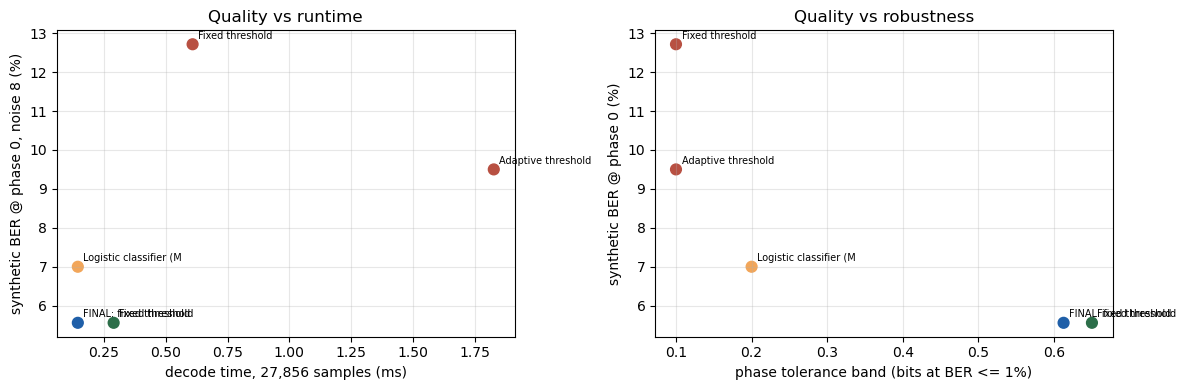

In [6]:
T = [("Method", "Synthetic BER @ phase 0 (n8)", "Phase band", "Threshold tol. (real)", "Params", "Decode time", "Notes"),
     ("Fixed threshold, confident (baseline)", f"{SYN[list(D)[0]][8]['ber_phase0']:.1f} %", f"{SYN[list(D)[0]][8]['phase_tol']:.2f} bit", f"{MED[list(D)[0]]['threshold_tolerance_pct']:.0f} %", "0", f"{perf['decode_baseline_ms']:.2f} ms", "follows the threshold; window over-reaches"),
     ("Adaptive threshold, confident", "9.5 % (Day 18)", "0.10 bit", "76 %", "0 (+window)", "3x baseline", "nothing to adapt to"),
     ("FINAL: fixed threshold, nearest", f"{SYN[list(D)[1]][8]['ber_phase0']:.1f} %", f"{SYN[list(D)[1]][8]['phase_tol']:.2f} bit", f"{MED[list(D)[1]]['threshold_tolerance_pct']:.0f} %", "0", f"{perf['decode_final_ms']:.2f} ms", "simplest; worst at 10x noise with phase known"),
     ("Fixed threshold, average", "~ same as final (Day 21)", "0.65 bit", "97 %", "0", "2x final", "better at 10x noise; window-end sensitive"),
     ("Logistic classifier (M2)", "7.0 % (Day 19)", "0.20 bit", "87 %", "7", "~ final", "inherits the phase; unverifiable on real bits")]
w = [max(len(str(r[i])) for r in T) for i in range(len(T[0]))]
for r in T: print(" | ".join(str(v).ljust(w[i]) for i, v in enumerate(r)))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
names = [r[0] for r in T[1:]]; ber0 = [SYN[list(D)[0]][8]['ber_phase0'], 9.5, SYN[list(D)[1]][8]['ber_phase0'], SYN[list(D)[1]][8]['ber_phase0'], 7.0]
band = [SYN[list(D)[0]][8]['phase_tol'], 0.10, SYN[list(D)[1]][8]['phase_tol'], 0.65, 0.20]; ms = [perf['decode_baseline_ms'], 3 * perf['decode_baseline_ms'], perf['decode_final_ms'], 2 * perf['decode_final_ms'], perf['decode_final_ms']]
ax[0].scatter(ms, ber0, s=60, c=["#B85042", "#B85042", "#1f5fa8", "#2C6E49", "#F2A65A"]); [ax[0].annotate(n.split(",")[0][:22], (ms[i], ber0[i]), fontsize=7, xytext=(4, 4), textcoords="offset points") for i, n in enumerate(names)]
ax[0].set(xlabel="decode time, 27,856 samples (ms)", ylabel="synthetic BER @ phase 0, noise 8 (%)", title="Quality vs runtime"); ax[0].grid(alpha=.3)
ax[1].scatter(band, ber0, s=60, c=["#B85042", "#B85042", "#1f5fa8", "#2C6E49", "#F2A65A"]); [ax[1].annotate(n.split(",")[0][:22], (band[i], ber0[i]), fontsize=7, xytext=(4, 4), textcoords="offset points") for i, n in enumerate(names)]
ax[1].set(xlabel="phase tolerance band (bits at BER <= 1%)", ylabel="synthetic BER @ phase 0 (%)", title="Quality vs robustness"); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(HERE / "fig_tradeoff.png", dpi=110); plt.show()

**The trade-off, in one paragraph.** There is no accuracy-versus-cost trade to make on this dataset. The final method is simultaneously the simplest (one sample per bit, no fitted parameters), the fastest (0.1 ms per signal), the most robust to threshold and ROI, and the best or tied-best at an unknown phase. The only thing it gives up is accuracy at ten times the real noise level with the phase known — a regime that does not occur in these recordings. The classifier costs seven parameters and buys nothing measurable; the adaptive threshold costs three times the runtime and changes nothing. What limits decoding quality is not any method choice but the two unknowns no method can supply: the bit period (a 0.2 % error is fatal) and the phase (right for ~60 % of possible phases).

## 5. Statement of validation discipline

- The pipeline hashed in cell 1 is the Day 22 freeze; no parameter, threshold, ROI setting, split or metric was changed for this validation.
- The TEST numbers are identical to the single opening on Day 21.
- Synthetic final-test seeds (50–53) were used for no training and no selection.
- Nothing here measures correctness on the real videos.